In [26]:
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

In [5]:

pasta_dados = Path(".")

arquivos = list(pasta_dados.glob("*.csv"))

lista_compra = []
lista_item = []
lista_resultado = []

print("Iniciando a leitura e separação dos arquivos...\n")

for caminho in arquivos:
    nome_arquivo = caminho.name
    print(f"Lendo: {nome_arquivo}")
    
    try:
        df_temp = pd.read_csv(caminho, sep=',', encoding='utf-8')
        
        if 'COMPRA_ITEM' in nome_arquivo:
            lista_item.append(df_temp)
        elif 'ITEM_RESULTADO' in nome_arquivo:
            lista_resultado.append(df_temp)
        elif 'COMPRA-' in nome_arquivo: 
            lista_compra.append(df_temp)
            
    except Exception as e:
        print(f"Erro ao ler {nome_arquivo}: {e}")

print("\nUnificando as bases...")

df_compra_final = pd.concat(lista_compra, ignore_index=True) if lista_compra else pd.DataFrame()
df_item_final = pd.concat(lista_item, ignore_index=True) if lista_item else pd.DataFrame()
df_resultado_final = pd.concat(lista_resultado, ignore_index=True) if lista_resultado else pd.DataFrame()

print(f"Base de COMPRAS: {df_compra_final.shape}")
print(f"Base de ITENS: {df_item_final.shape}")
print(f"Base de RESULTADOS: {df_resultado_final.shape}")

Iniciando a leitura e separação dos arquivos...

Lendo: comprasGOV-anual-VW_DM_PNCP_ITEM_RESULTADO-2024.csv


/var/folders/5d/czbd0byn7tnc1lb5z1xlgydm0000gn/T/ipykernel_85297/3723366969.py:20: DtypeWarning: Columns (1,5,34,39,44) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(caminho, sep=',', encoding='utf-8')


Lendo: comprasGOV-anual-VW_DM_PNCP_ITEM_RESULTADO-2025.csv


/var/folders/5d/czbd0byn7tnc1lb5z1xlgydm0000gn/T/ipykernel_85297/3723366969.py:20: DtypeWarning: Columns (5,34,39,44) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(caminho, sep=',', encoding='utf-8')


Lendo: comprasGOV-anual-VW_FT_PNCP_COMPRA_ITEM-2024.csv


...

Lendo: comprasGOV-anual-VW_FT_PNCP_COMPRA-2025.csv


/var/folders/5d/czbd0byn7tnc1lb5z1xlgydm0000gn/T/ipykernel_85297/3723366969.py:20: DtypeWarning: Columns (8,9,10,18,20,21,22) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(caminho, sep=',', encoding='utf-8')


Lendo: comprasGOV-anual-VW_FT_PNCP_COMPRA-2024.csv


/var/folders/5d/czbd0byn7tnc1lb5z1xlgydm0000gn/T/ipykernel_85297/3723366969.py:20: DtypeWarning: Columns (3,8,9,10,18,20,21,22,24) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(caminho, sep=',', encoding='utf-8')



Unificando as bases...
Base de COMPRAS: (618846, 72)
Base de ITENS: (6379194, 62)
Base de RESULTADOS: (4395570, 52)


In [6]:
df_compra_final.columns

Index(['cod_compra', 'modalidade_id_pncp', 'modo_disputa_id_pncp', 'id_compra',
       'ind_atual', 'valor_total_estimado', 'valor_total_homologado',
       'orgao_subrogado_cnpj', 'orgao_subrogado_razao_social',
       'orgao_subrogado_esfera_id', 'orgao_subrogado_poder_id', 'codigo_orgao',
       'unidade_orgao_uf_nome', 'unidade_orgao_codigo_unidade',
       'unidade_orgao_nome_unidade', 'unidade_orgao_uf_sigla',
       'unidade_orgao_municipio_nome', 'unidade_orgao_codigo_ibge',
       'unidade_subrogada_uf_nome', 'unidade_subrogada_codigo_unidade',
       'unidade_subrogada_nome_unidade', 'unidade_subrogada_uf_sigla',
       'unidade_subrogada_municipio_nome', 'unidade_subrogada_codigo_ibge',
       'numero_compra', 'data_atualizacao_pncp', 'data_publicacao_pncp',
       'codigo_modo_disputa', 'codigo_modalidade', 'srp', 'ano_compra_pncp',
       'sequencial_compra_pncp', 'orgao_entidade_cnpj',
       'orgao_entidade_razao_social', 'orgao_entidade_esfera_id',
       'orgao_entidad

In [7]:
df_item_final.columns

Index(['srk_pncp_item_compra', 'cod_compra', 'cod_item_compra',
       'codigo_classe', 'codigo_grupo', 'numero_item', 'numero_grupo',
       'numero_item_compra', 'descricao_detalhada', 'descricao',
       'material_ou_servico', 'material_ou_servico_nome',
       'valor_unitario_estimado', 'valor_total', 'quantidade',
       'unidade_medida', 'orcamento_sigiloso', 'item_categoria_id',
       'item_categoria_nome', 'patrimonio', 'codigo_registro_imobiliario',
       'criterio_julgamento_id', 'criterio_julgamento_nome',
       'situacao_compra_item', 'situacao_compra_item_nome', 'tipo_beneficio',
       'tipo_beneficio_nome', 'incentivo_produtivo_basico', 'data_inclusao',
       'data_atualizacao', 'tem_resultado', 'cod_item_catalogo',
       'ID_contratacao_PNCP', 'cod_fornecedor', 'nome_fornecedor',
       'data_resultado', 'valor_total_resultado', 'valor_unitario_resultado',
       'quantidade_resultado', 'id_compra', 'id_compra_item', 'ano_compra',
       'sequencial_compra', 'orgao

In [8]:
df_resultado_final.columns

Index(['srk_item_resultado', 'id_compra', 'id_compra_item',
       'id_contratacao_pncp', 'data_atualizacao', 'ni_fornecedor',
       'tipo_pessoa', 'data_inclusao', 'numero_item', 'data_cancelamento',
       'nome_razao_social_fornecedor', 'codigo_pais', 'porte_fornecedor_id',
       'quantidade_homologada', 'valor_unitario_homologado',
       'valor_total_homologado', 'percentual_desconto',
       'indicador_subcontratacao', 'ordem_classificacao_srp', 'data_resultado',
       'motivo_cancelamento', 'numero_controle_PNCP_compra',
       'porte_fornecedor_nome', 'situacao_compra_item_resultado_nome',
       'sequencial_resultado', 'natureza_juridica_nome',
       'natureza_juridica_id', 'situacao_compra_item_resultado_id',
       'orgao_entidade_cnpj', 'sequencial_compra', 'ano_compra',
       'unidade_orgao_codigo_unidade', 'aplicacao_margem_preferencia',
       'amparo_legal_margem_preferencia_id',
       'amparo_legal_margem_preferencia_nome',
       'amparo_legal_margem_preferencia

In [9]:
df_compra_final["id_compra"].nunique(), len(df_compra_final)

(616627, 618846)

In [10]:
df_item_final[["id_compra", "id_compra_item"]].drop_duplicates().shape[0], len(df_item_final)

(6133559, 6379194)

In [11]:
df_resultado_final.groupby(["id_compra", "id_compra_item"]).size().describe()

count    4.267209e+06
mean     1.030081e+00
std      1.646963e+00
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.930000e+03
dtype: float64

In [12]:
print("COMPRA")
print(df_compra_final.shape)
print(df_compra_final["id_compra"].nunique())

print("\nITEM")
print(df_item_final.shape)
print(df_item_final[["id_compra", "id_compra_item"]].drop_duplicates().shape[0])

print("\nRESULTADO")
print(df_resultado_final.shape)
print(df_resultado_final[["id_compra", "id_compra_item", "sequencial_resultado"]].drop_duplicates().shape[0])

print("\nMultiplicidade de resultado por item")
print(
    df_resultado_final
    .groupby(["id_compra", "id_compra_item"])
    .size()
    .describe()
)

COMPRA
(618846, 72)
616627

ITEM
(6379194, 62)
6133559

RESULTADO
(4395570, 52)
4390513

Multiplicidade de resultado por item
count    4.267209e+06
mean     1.030081e+00
std      1.646963e+00
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.930000e+03
dtype: float64


In [14]:
df_resultado_final["situacao_compra_item_resultado_nome"].value_counts(dropna=False)

situacao_compra_item_resultado_nome
Informado    4323717
Cancelado      71853
Name: count, dtype: int64

In [15]:

df_compra = df_compra_final.copy()
df_item = df_item_final.copy()
df_resultado = df_resultado_final.copy()

# =========================================================
# 2) PADRONIZAÇÃO BÁSICA DE TIPOS
# =========================================================
# Evita problemas de merge por tipo inconsistente

colunas_id_compra = ["id_compra"]
colunas_id_item = ["id_compra", "id_compra_item"]

for col in colunas_id_compra:
    if col in df_compra.columns:
        df_compra[col] = df_compra[col].astype(str)
    if col in df_item.columns:
        df_item[col] = df_item[col].astype(str)
    if col in df_resultado.columns:
        df_resultado[col] = df_resultado[col].astype(str)

for col in ["id_compra_item"]:
    if col in df_item.columns:
        df_item[col] = df_item[col].astype(str)
    if col in df_resultado.columns:
        df_resultado[col] = df_resultado[col].astype(str)

# =========================================================
# 3) FILTRAR RESULTADOS VÁLIDOS
# =========================================================
# - Informado
# - Cancelado

df_resultado = df_resultado[
    df_resultado["situacao_compra_item_resultado_nome"] == "Informado"
].copy()

print("Após filtro de resultado = Informado:")
print(df_resultado.shape)

# =========================================================
# 4) DEDUPLICAÇÃO
# =========================================================
# COMPRA: 1 linha por id_compra
# ITEM: 1 linha por (id_compra, id_compra_item)
# RESULTADO: idealmente 1 linha por (id_compra, id_compra_item)
#
# Como pode haver mais de um resultado por item, vamos ordenar
# e manter o registro mais recente / mais estável se possível.d

# ---------- COMPRA ----------
df_compra = df_compra.sort_values(
    by=["id_compra", "data_atualizacao_pncp"],
    ascending=[True, False],
    na_position="last"
).drop_duplicates(subset=["id_compra"], keep="first").copy()

print("\nCOMPRA deduplicada:")
print(df_compra.shape)

# ---------- ITEM ----------
col_ordenacao_item = [c for c in ["id_compra", "id_compra_item", "data_atualizacao_pncp", "data_atualizacao"] if c in df_item.columns]

df_item = df_item.sort_values(
    by=col_ordenacao_item,
    ascending=[True] * max(len(col_ordenacao_item) - 2, 0) + [False, False] if len(col_ordenacao_item) >= 2 else True,
    na_position="last"
).drop_duplicates(subset=["id_compra", "id_compra_item"], keep="first").copy()

print("\nITEM deduplicado:")
print(df_item.shape)

# ---------- RESULTADO ----------
# Estratégia:
# 1. ordenar pelo item
# 2. priorizar data_resultado_pncp mais recente
# 3. priorizar data_atualizacao_pncp mais recente
# 4. manter 1 por (id_compra, id_compra_item)

colunas_ordenacao_resultado = [
    c for c in [
        "id_compra", "id_compra_item",
        "data_resultado_pncp",
        "data_atualizacao_pncp",
        "data_resultado",
        "data_atualizacao",
        "sequencial_resultado"
    ] if c in df_resultado.columns
]

ascending_resultado = []
for c in colunas_ordenacao_resultado:
    if c in ["id_compra", "id_compra_item"]:
        ascending_resultado.append(True)
    else:
        ascending_resultado.append(False)

df_resultado = df_resultado.sort_values(
    by=colunas_ordenacao_resultado,
    ascending=ascending_resultado,
    na_position="last"
).drop_duplicates(subset=["id_compra", "id_compra_item"], keep="first").copy()

print("\nRESULTADO deduplicado:")
print(df_resultado.shape)

# =========================================================
# 5) VALIDAÇÕES DE UNICIDADE
# =========================================================
print("\nValidações de unicidade:")

print("COMPRA")
print("linhas:", len(df_compra))
print("id_compra únicos:", df_compra["id_compra"].nunique())

print("\nITEM")
print("linhas:", len(df_item))
print(
    "pares únicos:",
    df_item[["id_compra", "id_compra_item"]].drop_duplicates().shape[0]
)

print("\nRESULTADO")
print("linhas:", len(df_resultado))
print(
    "pares únicos:",
    df_resultado[["id_compra", "id_compra_item"]].drop_duplicates().shape[0]
)

# =========================================================
# 6) SELEÇÃO DE COLUNAS IMPORTANTES PARA O MERGE
# =========================================================
# Isso ajuda a evitar dataframe gigante e colunas repetidas demais

colunas_compra = [
    "id_compra",
    "valor_total_estimado",
    "valor_total_homologado",
    "orgao_entidade_cnpj",
    "orgao_entidade_razao_social",
    "unidade_orgao_codigo_unidade",
    "unidade_orgao_uf_sigla",
    "unidade_orgao_municipio_nome",
    "modalidade_nome",
    "modo_disputa_nome_pncp",
    "data_publicacao_pncp",
    "data_abertura_proposta_pncp",
    "data_encerramento_proposta_pncp",
    "objeto_compra",
    "numero_controle_PNCP",
    "ano_compra",
    "sequencial_compra",
    "situacao_compra_nome_pncp"
]

colunas_item = [
    "id_compra",
    "id_compra_item",
    "numero_item",
    "numero_item_pncp",
    "descricao",
    "descricao_detalhada",
    "descricao_resumida",
    "codigo_classe",
    "codigo_grupo",
    "codigo_NCM",
    "descricao_NCM",
    "material_ou_servico",
    "material_ou_servico_nome",
    "valor_unitario_estimado",
    "valor_total",
    "quantidade",
    "unidade_medida",
    "item_categoria_nome",
    "criterio_julgamento_nome",
    "situacao_compra_item_nome",
    "tem_resultado",
    "numero_controle_PNCP_compra"
]

colunas_resultado = [
    "id_compra",
    "id_compra_item",
    "ni_fornecedor",
    "nome_razao_social_fornecedor",
    "tipo_pessoa",
    "porte_fornecedor_nome",
    "natureza_juridica_nome",
    "quantidade_homologada",
    "valor_unitario_homologado",
    "valor_total_homologado",
    "percentual_desconto",
    "ordem_classificacao_srp",
    "data_resultado",
    "data_resultado_pncp",
    "situacao_compra_item_resultado_nome",
    "sequencial_resultado",
    "numero_item",
    "numero_item_pncp",
    "numero_controle_PNCP_compra",
    "orgao_entidade_cnpj",
    "unidade_orgao_codigo_unidade",
    "unidade_orgao_uf_sigla"
]

colunas_compra = [c for c in colunas_compra if c in df_compra.columns]
colunas_item = [c for c in colunas_item if c in df_item.columns]
colunas_resultado = [c for c in colunas_resultado if c in df_resultado.columns]

df_compra_sub = df_compra[colunas_compra].copy()
df_item_sub = df_item[colunas_item].copy()
df_resultado_sub = df_resultado[colunas_resultado].copy()

# =========================================================
# 7) MERGE RESULTADO + ITEM
# =========================================================
# Base principal = resultado
# Enriquecemos com item

df_base = df_resultado_sub.merge(
    df_item_sub,
    on=["id_compra", "id_compra_item"],
    how="left",
    suffixes=("_resultado", "_item")
)

print("\nApós merge resultado + item:")
print(df_base.shape)

# =========================================================
# 8) MERGE COM COMPRA
# =========================================================

df_base = df_base.merge(
    df_compra_sub,
    on="id_compra",
    how="left",
    suffixes=("", "_compra")
)

print("\nApós merge com compra:")
print(df_base.shape)

# =========================================================
# 9) VALIDAÇÃO DO MERGE
# =========================================================
# A quantidade de linhas da base final deve ficar próxima
# da base de resultado deduplicada

print("\nValidação pós-merge:")
print("Linhas df_resultado_sub:", len(df_resultado_sub))
print("Linhas df_base:", len(df_base))

if len(df_base) > len(df_resultado_sub) * 1.05:
    print("ALERTA: houve aumento relevante de linhas após merge. Verificar cardinalidade.")
else:
    print("Merge aparentemente consistente.")

# =========================================================
# 10) CONVERSÃO DE COLUNAS NUMÉRICAS
# =========================================================

colunas_numericas = [
    "valor_unitario_estimado",
    "valor_total",
    "quantidade",
    "quantidade_homologada",
    "valor_unitario_homologado",
    "valor_total_homologado",
    "percentual_desconto",
    "valor_total_estimado",
    "valor_total_homologado"
]

for col in colunas_numericas:
    if col in df_base.columns:
        df_base[col] = pd.to_numeric(df_base[col], errors="coerce")

# =========================================================
# 11) CONVERSÃO DE DATAS
# =========================================================

colunas_data = [
    "data_resultado",
    "data_resultado_pncp",
    "data_publicacao_pncp",
    "data_abertura_proposta_pncp",
    "data_encerramento_proposta_pncp"
]

for col in colunas_data:
    if col in df_base.columns:
        df_base[col] = pd.to_datetime(df_base[col], errors="coerce")



Após filtro de resultado = Informado:
(4323717, 52)

COMPRA deduplicada:
(616590, 72)

ITEM deduplicado:
(6131109, 62)

RESULTADO deduplicado:
(4250870, 52)

Validações de unicidade:
COMPRA
linhas: 616590
id_compra únicos: 616590

ITEM
linhas: 6131109
pares únicos: 6131109

RESULTADO
linhas: 4250870
pares únicos: 4250870

Após merge resultado + item:
(4250870, 42)

Após merge com compra:
(4250870, 59)

Validação pós-merge:
Linhas df_resultado_sub: 4250870
Linhas df_base: 4250870
Merge aparentemente consistente.


In [18]:
# =========================================================
# 12) FEATURE ENGINEERING INICIAL
# =========================================================

# ---------- Razões e diferenças de preço ----------
if {"valor_unitario_homologado", "valor_unitario_estimado"}.issubset(df_base.columns):
    df_base["ratio_preco_unitario"] = np.where(
        (df_base["valor_unitario_estimado"].notna()) &
        (df_base["valor_unitario_estimado"] > 0),
        df_base["valor_unitario_homologado"] / df_base["valor_unitario_estimado"],
        np.nan
    )

    df_base["diff_preco_unitario"] = (
        df_base["valor_unitario_homologado"] - df_base["valor_unitario_estimado"]
    )

    df_base["diff_preco_unitario_pct"] = np.where(
        (df_base["valor_unitario_estimado"].notna()) &
        (df_base["valor_unitario_estimado"] > 0),
        (df_base["valor_unitario_homologado"] - df_base["valor_unitario_estimado"]) /
        df_base["valor_unitario_estimado"],
        np.nan
    )

# ---------- Razões e diferenças totais ----------
if {"valor_total_homologado", "valor_total"}.issubset(df_base.columns):
    df_base["ratio_preco_total"] = np.where(
        (df_base["valor_total"].notna()) &
        (df_base["valor_total"] > 0),
        df_base["valor_total_homologado"] / df_base["valor_total"],
        np.nan
    )

    df_base["diff_preco_total"] = (
        df_base["valor_total_homologado"] - df_base["valor_total"]
    )

# ---------- Log dos valores ----------
if "valor_unitario_homologado" in df_base.columns:
    df_base["log_valor_unitario_homologado"] = np.log1p(
        df_base["valor_unitario_homologado"].clip(lower=0)
    )

if "valor_total_homologado" in df_base.columns:
    df_base["log_valor_total_homologado"] = np.log1p(
        df_base["valor_total_homologado"].clip(lower=0)
    )

# ---------- Tempo entre etapas ----------
if {"data_publicacao_pncp", "data_abertura_proposta_pncp"}.issubset(df_base.columns):
    df_base["dias_publicacao_ate_abertura"] = (
        df_base["data_abertura_proposta_pncp"] - df_base["data_publicacao_pncp"]
    ).dt.days

if {"data_abertura_proposta_pncp", "data_encerramento_proposta_pncp"}.issubset(df_base.columns):
    df_base["dias_abertura_ate_encerramento"] = (
        df_base["data_encerramento_proposta_pncp"] - df_base["data_abertura_proposta_pncp"]
    ).dt.days

if {"data_publicacao_pncp", "data_resultado_pncp"}.issubset(df_base.columns):
    df_base["dias_publicacao_ate_resultado"] = (
        df_base["data_resultado_pncp"] - df_base["data_publicacao_pncp"]
    ).dt.days

# ---------- Features temporais ----------
if "data_resultado_pncp" in df_base.columns:
    df_base["ano_resultado"] = df_base["data_resultado_pncp"].dt.year
    df_base["mes_resultado"] = df_base["data_resultado_pncp"].dt.month
    df_base["dia_semana_resultado"] = df_base["data_resultado_pncp"].dt.dayofweek

# ---------- Frequência do fornecedor ----------
if "ni_fornecedor" in df_base.columns:
    freq_fornecedor_abs = df_base["ni_fornecedor"].value_counts(dropna=False)
    freq_fornecedor_rel = df_base["ni_fornecedor"].value_counts(normalize=True, dropna=False)

    df_base["freq_fornecedor_abs"] = df_base["ni_fornecedor"].map(freq_fornecedor_abs)
    df_base["freq_fornecedor_rel"] = df_base["ni_fornecedor"].map(freq_fornecedor_rel)

# ---------- Frequência fornecedor por órgão ----------
if {"orgao_entidade_cnpj", "ni_fornecedor"}.issubset(df_base.columns):
    df_base["freq_fornecedor_orgao"] = (
        df_base
        .groupby(["orgao_entidade_cnpj", "ni_fornecedor"])["id_compra"]
        .transform("count")
    )

# ---------- Frequência fornecedor por UF ----------
if {"unidade_orgao_uf_sigla", "ni_fornecedor"}.issubset(df_base.columns):
    df_base["freq_fornecedor_uf"] = (
        df_base
        .groupby(["unidade_orgao_uf_sigla", "ni_fornecedor"])["id_compra"]
        .transform("count")
    )

# ---------- Comparação com média por classe ----------
if {"codigo_classe", "valor_unitario_homologado"}.issubset(df_base.columns):
    media_classe = (
        df_base
        .groupby("codigo_classe")["valor_unitario_homologado"]
        .transform("mean")
    )
    mediana_classe = (
        df_base
        .groupby("codigo_classe")["valor_unitario_homologado"]
        .transform("median")
    )

    df_base["media_valor_classe"] = media_classe
    df_base["mediana_valor_classe"] = mediana_classe

    df_base["ratio_vs_media_classe"] = np.where(
        media_classe > 0,
        df_base["valor_unitario_homologado"] / media_classe,
        np.nan
    )

    df_base["ratio_vs_mediana_classe"] = np.where(
        mediana_classe > 0,
        df_base["valor_unitario_homologado"] / mediana_classe,
        np.nan
    )

# ---------- Comparação com média por NCM ----------
if {"codigo_NCM", "valor_unitario_homologado"}.issubset(df_base.columns):
    media_ncm = (
        df_base
        .groupby("codigo_NCM")["valor_unitario_homologado"]
        .transform("mean")
    )
    df_base["media_valor_ncm"] = media_ncm
    df_base["ratio_vs_media_ncm"] = np.where(
        media_ncm > 0,
        df_base["valor_unitario_homologado"] / media_ncm,
        np.nan
    )

# ---------- Quantidade homologada x quantidade estimada ----------
if {"quantidade_homologada", "quantidade"}.issubset(df_base.columns):
    df_base["ratio_quantidade"] = np.where(
        (df_base["quantidade"].notna()) & (df_base["quantidade"] > 0),
        df_base["quantidade_homologada"] / df_base["quantidade"],
        np.nan
    )

# =========================================================
# 13) INSPEÇÕES RÁPIDAS
# =========================================================
print("\nResumo da base final:")
print(df_base.shape)

print("\nPercentual de nulos (top 20):")
print(
    df_base.isnull()
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

colunas_resumo = [
    "valor_unitario_estimado",
    "valor_unitario_homologado",
    "ratio_preco_unitario",
    "diff_preco_unitario",
    "valor_total",
    "valor_total_homologado",
    "ratio_preco_total",
    "percentual_desconto",
    "freq_fornecedor_abs",
    "freq_fornecedor_orgao",
    "ratio_vs_media_classe",
    "dias_publicacao_ate_resultado"
]

colunas_resumo = [c for c in colunas_resumo if c in df_base.columns]

print("\nEstatísticas descritivas das principais variáveis:")
print(df_base[colunas_resumo].describe())

# =========================================================
# 14) CHECKS IMPORTANTES PARA A EDA
# =========================================================
print("\nTop status de resultado:")
if "situacao_compra_item_resultado_nome" in df_base.columns:
    print(df_base["situacao_compra_item_resultado_nome"].value_counts(dropna=False).head(10))

print("\nTop modalidades:")
if "modalidade_nome" in df_base.columns:
    print(df_base["modalidade_nome"].value_counts(dropna=False).head(10))

print("\nTop UFs:")
if "unidade_orgao_uf_sigla" in df_base.columns:
    print(df_base["unidade_orgao_uf_sigla"].value_counts(dropna=False).head(10))

# =========================================================
# 15) SALVAR BASE FINAL
# =========================================================
# Salva em parquet, que é muito melhor que CSV para esse volume

try:
    df_base.to_parquet("base_analitica_licitacoes.parquet", index=False)
    print("\nBase salva com sucesso em: base_analitica_licitacoes.parquet")
except Exception as e:
    print(f"\nNão foi possível salvar em parquet: {e}")
    print("Tentando salvar em CSV...")
    try:
        df_base.to_csv("base_analitica_licitacoes.csv", index=False)
        print("Base salva com sucesso em: base_analitica_licitacoes.csv")
    except Exception as e2:
        print(f"Erro ao salvar CSV: {e2}")


Resumo da base final:
(4250870, 83)

Percentual de nulos (top 20):
descricao_NCM                      1.000000
codigo_NCM                         0.958660
ratio_vs_media_ncm                 0.958660
media_valor_ncm                    0.958660
codigo_grupo                       0.835967
descricao                          0.773082
numero_item_item                   0.773082
data_encerramento_proposta_pncp    0.585251
dias_abertura_ate_encerramento     0.585251
data_abertura_proposta_pncp        0.585251
dias_publicacao_ate_abertura       0.585251
numero_item_resultado              0.547706
data_resultado                     0.547706
modo_disputa_nome_pncp             0.520206
situacao_compra_nome_pncp          0.520206
sequencial_compra                  0.507395
ano_compra                         0.507395
dias_publicacao_ate_resultado      0.455821
mes_resultado                      0.452294
ano_resultado                      0.452294
dtype: float64

Estatísticas descritivas das princip

In [19]:

df_modelo = df_base.copy()

df_modelo = df_modelo.replace([np.inf, -np.inf], np.nan)

if "valor_unitario_estimado" in df_modelo.columns:
    df_modelo["flag_valor_unitario_estimado_zero_ou_nulo"] = (
        df_modelo["valor_unitario_estimado"].isna() |
        (df_modelo["valor_unitario_estimado"] <= 0)
    ).astype(int)

if "valor_total" in df_modelo.columns:
    df_modelo["flag_valor_total_zero_ou_nulo"] = (
        df_modelo["valor_total"].isna() |
        (df_modelo["valor_total"] <= 0)
    ).astype(int)

if "dias_publicacao_ate_resultado" in df_modelo.columns:
    df_modelo["flag_data_negativa_resultado"] = (
        df_modelo["dias_publicacao_ate_resultado"] < 0
    ).astype(int)

if "unidade_orgao_uf_sigla" in df_modelo.columns:
    df_modelo["flag_uf_ausente"] = df_modelo["unidade_orgao_uf_sigla"].isna().astype(int)
    df_modelo["unidade_orgao_uf_sigla"] = df_modelo["unidade_orgao_uf_sigla"].fillna("NAO_INFORMADA")


if "dias_publicacao_ate_resultado" in df_modelo.columns:
    df_modelo.loc[
        (df_modelo["dias_publicacao_ate_resultado"] < 0) |
        (df_modelo["dias_publicacao_ate_resultado"] > 3650),
        "dias_publicacao_ate_resultado"
    ] = np.nan

if "dias_publicacao_ate_abertura" in df_modelo.columns:
    df_modelo.loc[
        (df_modelo["dias_publicacao_ate_abertura"] < 0) |
        (df_modelo["dias_publicacao_ate_abertura"] > 3650),
        "dias_publicacao_ate_abertura"
    ] = np.nan

if "dias_abertura_ate_encerramento" in df_modelo.columns:
    df_modelo.loc[
        (df_modelo["dias_abertura_ate_encerramento"] < 0) |
        (df_modelo["dias_abertura_ate_encerramento"] > 3650),
        "dias_abertura_ate_encerramento"
    ] = np.nan


colunas_monetarias = [
    "valor_unitario_estimado",
    "valor_unitario_homologado",
    "valor_total",
    "valor_total_homologado"
]

for col in colunas_monetarias:
    if col in df_modelo.columns:
        df_modelo[f"log_{col}"] = np.log1p(df_modelo[col].clip(lower=0))


def winsorizar_serie(s, p_inf=0.01, p_sup=0.99):
    if s.notna().sum() == 0:
        return s
    li = s.quantile(p_inf)
    ls = s.quantile(p_sup)
    return s.clip(lower=li, upper=ls)

colunas_ratio = [
    "ratio_preco_unitario",
    "ratio_preco_total",
    "ratio_vs_media_classe",
    "ratio_vs_mediana_classe",
    "ratio_quantidade"
]

for col in colunas_ratio:
    if col in df_modelo.columns:
        df_modelo[f"{col}_wins"] = winsorizar_serie(df_modelo[col])

colunas_nulos = df_modelo.isnull().mean()
colunas_descartar = colunas_nulos[colunas_nulos > 0.90].index.tolist()

print("Colunas com mais de 90% de nulos:")
print(colunas_descartar)

df_modelo = df_modelo.drop(columns=colunas_descartar)

print("\nShape após limpeza inicial:")
print(df_modelo.shape)


colunas_check = [
    "ratio_preco_unitario",
    "ratio_preco_unitario_wins",
    "ratio_preco_total",
    "ratio_preco_total_wins",
    "ratio_vs_media_classe",
    "ratio_vs_media_classe_wins",
    "dias_publicacao_ate_resultado",
    "log_valor_unitario_homologado",
    "log_valor_total_homologado"
]

colunas_check = [c for c in colunas_check if c in df_modelo.columns]

print("\nResumo pós-limpeza:")
print(df_modelo[colunas_check].describe())


df_modelo.to_csv("base_analitica_licitacoes_tratada.csv", index=False)
print("\nBase tratada salva em: base_analitica_licitacoes_tratada.csv")

Colunas com mais de 90% de nulos:
['codigo_NCM', 'descricao_NCM', 'media_valor_ncm', 'ratio_vs_media_ncm']

Shape após limpeza inicial:
(4250870, 90)

Resumo pós-limpeza:
       ratio_preco_unitario  ratio_preco_unitario_wins  ratio_preco_total  \
count          4.219413e+06               4.219413e+06       4.218918e+06   
mean           5.251872e+04               7.400636e-01       6.364744e+04   
std            4.541435e+07               2.531149e-01       4.714383e+07   
min            0.000000e+00               1.020052e-01       0.000000e+00   
25%            5.499852e-01               5.499852e-01       5.461287e-01   
50%            7.989418e-01               7.989418e-01       7.954654e-01   
75%            9.922482e-01               9.922482e-01       9.909512e-01   
max            6.400000e+10               1.000000e+00       6.400000e+10   

       ratio_preco_total_wins  ratio_vs_media_classe  \
count            4.218918e+06           3.419250e+06   
mean             7.3711

In [22]:
df_tratado = pd.read_csv("base_analitica_licitacoes_tratada.csv")

/var/folders/5d/czbd0byn7tnc1lb5z1xlgydm0000gn/T/ipykernel_85297/1996368846.py:1: DtypeWarning: Columns (0,2,12,24,38) have mixed types. Specify dtype option on import or set low_memory=False.
  df_tratado = pd.read_csv("base_analitica_licitacoes_tratada.csv")


In [29]:
df_tratado.columns

Index(['id_compra', 'id_compra_item', 'ni_fornecedor',
       'nome_razao_social_fornecedor', 'tipo_pessoa', 'porte_fornecedor_nome',
       'natureza_juridica_nome', 'quantidade_homologada',
       'valor_unitario_homologado', 'valor_total_homologado',
       'percentual_desconto', 'ordem_classificacao_srp', 'data_resultado',
       'data_resultado_pncp', 'situacao_compra_item_resultado_nome',
       'sequencial_resultado', 'numero_item_resultado',
       'numero_item_pncp_resultado', 'numero_controle_PNCP_compra_resultado',
       'orgao_entidade_cnpj', 'unidade_orgao_codigo_unidade',
       'unidade_orgao_uf_sigla', 'numero_item_item', 'numero_item_pncp_item',
       'descricao', 'descricao_detalhada', 'descricao_resumida',
       'codigo_classe', 'codigo_grupo', 'material_ou_servico',
       'material_ou_servico_nome', 'valor_unitario_estimado', 'valor_total',
       'quantidade', 'unidade_medida', 'item_categoria_nome',
       'criterio_julgamento_nome', 'situacao_compra_item_nome

In [30]:
df_tratado = pd.read_csv("base_analitica_licitacoes_tratada.csv")

# converter datas
for col in ["data_publicacao_pncp", "data_resultado", "data_resultado_pncp"]:
    if col in df_tratado.columns:
        df_tratado[col] = pd.to_datetime(df_tratado[col], errors="coerce")

# criar flag usando as colunas que realmente existem
if "data_publicacao_pncp" in df_tratado.columns and "data_resultado_pncp" in df_tratado.columns:
    df_tratado["flag_publicacao_retroativa"] = (
        df_tratado["data_resultado_pncp"] < df_tratado["data_publicacao_pncp"]
    ).astype(int)

elif "data_publicacao_pncp" in df_tratado.columns and "data_resultado" in df_tratado.columns:
    df_tratado["flag_publicacao_retroativa"] = (
        df_tratado["data_resultado"] < df_tratado["data_publicacao_pncp"]
    ).astype(int)

else:
    print("Não encontrei colunas de data suficientes para criar a flag.")

/var/folders/5d/czbd0byn7tnc1lb5z1xlgydm0000gn/T/ipykernel_85297/1024174284.py:1: DtypeWarning: Columns (0,2,12,24,38) have mixed types. Specify dtype option on import or set low_memory=False.
  df_tratado = pd.read_csv("base_analitica_licitacoes_tratada.csv")


In [31]:
if "id_compra" in df_tratado.columns and "id_compra_item" in df_tratado.columns:
    df_tratado["qtd_itens_compra"] = (
        df_tratado.groupby("id_compra")["id_compra_item"]
        .transform("nunique")
    )
else:
    raise ValueError("Não encontrei id_compra e id_compra_item para criar qtd_itens_compra.")

# -------------------------
# 4. análises rápidas
# -------------------------
print(df_tratado["flag_publicacao_retroativa"].value_counts(dropna=False))

print(
    df_tratado.groupby("flag_publicacao_retroativa")["ratio_preco_total_wins"]
    .describe()
)

print(
    df_tratado.groupby("flag_publicacao_retroativa")["qtd_itens_compra"]
    .mean()
)

flag_publicacao_retroativa
0    3978898
1     271972
Name: count, dtype: int64
                                count      mean       std       min       25%  \
flag_publicacao_retroativa                                                      
0                           3947255.0  0.723713  0.252313  0.090074  0.533333   
1                            271663.0  0.931822  0.212521  0.090074  1.000000   

                                 50%       75%  max  
flag_publicacao_retroativa                           
0                           0.769769  0.973463  1.0  
1                           1.000000  1.000000  1.0  
flag_publicacao_retroativa
0    119.741716
1     20.614740
Name: qtd_itens_compra, dtype: float64


Distribuição do indicador principal (eficiência)

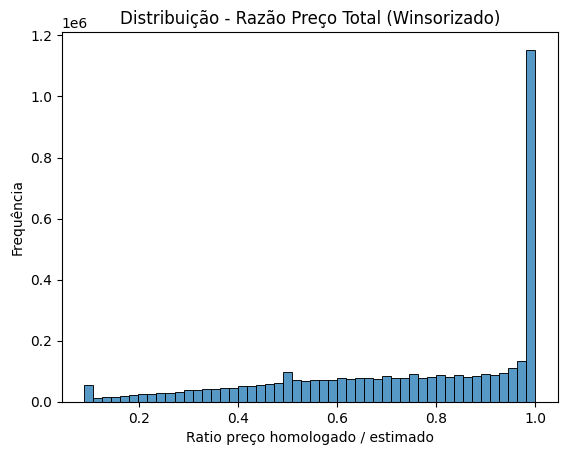

In [32]:
sns.histplot(df_tratado["ratio_preco_total_wins"], bins=50)
plt.title("Distribuição - Razão Preço Total (Winsorizado)")
plt.xlabel("Ratio preço homologado / estimado")
plt.ylabel("Frequência")
plt.show()

Tamanho do fenômeno de publicação retroativa

In [33]:
df_tratado["flag_publicacao_retroativa"].value_counts(normalize=True)

flag_publicacao_retroativa
0    0.93602
1    0.06398
Name: proportion, dtype: float64

Impacto da publicação retroativa na eficiência

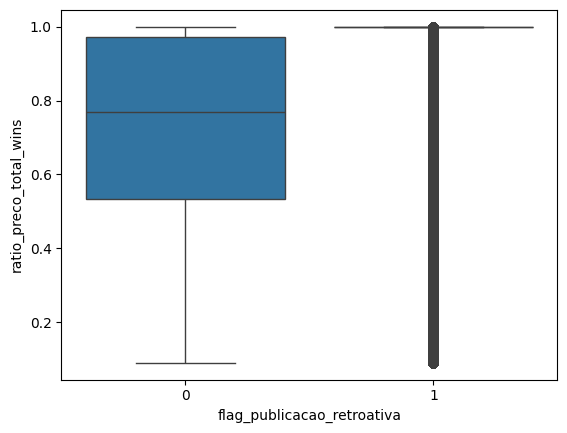

In [34]:
df_tratado.groupby("flag_publicacao_retroativa")["ratio_preco_total_wins"].mean()

sns.boxplot(
    x="flag_publicacao_retroativa",
    y="ratio_preco_total_wins",
    data=df_tratado
)
plt.show()

Tempo do processo vs eficiência

In [40]:
df_tratado["bucket_tempo"] = pd.qcut(
    df_tratado["dias_publicacao_ate_resultado"],
    q=5,
    duplicates="drop"
)

df_tratado.groupby("bucket_tempo")["ratio_preco_total_wins"].mean()

/var/folders/5d/czbd0byn7tnc1lb5z1xlgydm0000gn/T/ipykernel_85297/476528772.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_tratado.groupby("bucket_tempo")["ratio_preco_total_wins"].mean()


bucket_tempo
(-0.001, 20.0]    0.760491
(20.0, 33.0]      0.712634
(33.0, 49.0]      0.700773
(49.0, 79.0]      0.697165
(79.0, 860.0]     0.687014
Name: ratio_preco_total_wins, dtype: float64

Tamanho da compra vs eficiência

In [36]:
df_tratado["bucket_valor"] = pd.qcut(
    df_tratado["valor_total_homologado"],
    q=5,
    duplicates="drop"
)

df_tratado.groupby("bucket_valor")["ratio_preco_total_wins"].mean()

/var/folders/5d/czbd0byn7tnc1lb5z1xlgydm0000gn/T/ipykernel_85297/3171025783.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_tratado.groupby("bucket_valor")["ratio_preco_total_wins"].mean()


bucket_valor
(-0.001, 378.0]                0.715077
(378.0, 1434.0]                0.726482
(1434.0, 4888.9]               0.735862
(4888.9, 21841.64]             0.738717
(21841.64, 2900208000000.0]    0.769155
Name: ratio_preco_total_wins, dtype: float64

Complexidade (quantidade de itens)

In [43]:
df_tratado.groupby("qtd_itens_compra")["ratio_preco_total_wins"].mean().head(20)

qtd_itens_compra
1     0.856367
2     0.811211
3     0.801681
4     0.790730
5     0.788622
6     0.783019
7     0.779820
8     0.778286
9     0.773726
10    0.774307
11    0.777448
12    0.768575
13    0.769392
14    0.766204
15    0.764283
16    0.763170
17    0.757899
18    0.759023
19    0.757776
20    0.758165
Name: ratio_preco_total_wins, dtype: float64

In [44]:
df_tratado["bucket_itens"] = pd.qcut(
    df_tratado["qtd_itens_compra"],
    q=5,
    duplicates="drop"
)

df_tratado.groupby("bucket_itens")["ratio_preco_total_wins"].mean()

/var/folders/5d/czbd0byn7tnc1lb5z1xlgydm0000gn/T/ipykernel_85297/4168026150.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_tratado.groupby("bucket_itens")["ratio_preco_total_wins"].mean()


bucket_itens
(0.999, 9.0]       0.813607
(9.0, 30.0]        0.760178
(30.0, 67.0]       0.731473
(67.0, 152.0]      0.696875
(152.0, 3590.0]    0.681193
Name: ratio_preco_total_wins, dtype: float64

Correlação geral

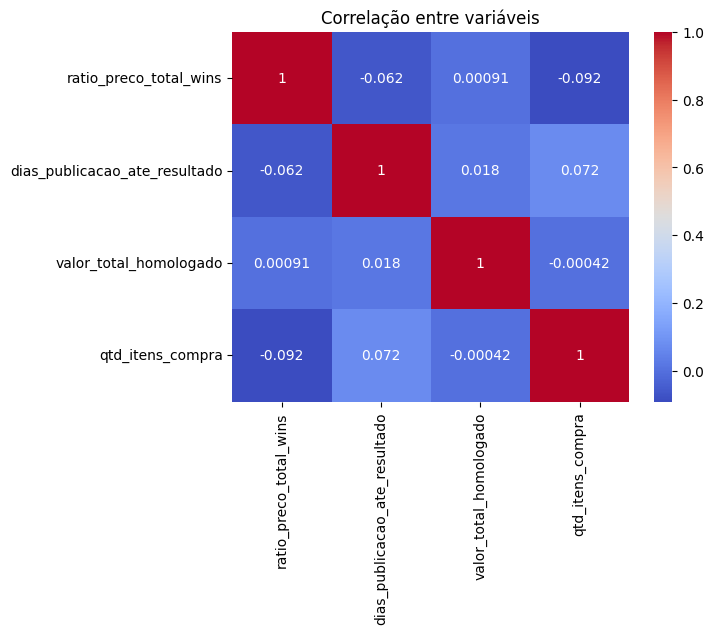

In [41]:
cols = [
    "ratio_preco_total_wins",
    "dias_publicacao_ate_resultado",
    "valor_total_homologado",
    "qtd_itens_compra"
]

sns.heatmap(df_tratado[cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlação entre variáveis")
plt.show()

Transformando em métrica de economia

In [42]:
df_tratado["economia"] = 1 - df_tratado["ratio_preco_total_wins"]

df_tratado.groupby("flag_publicacao_retroativa")["economia"].mean()

flag_publicacao_retroativa
0    0.276287
1    0.068178
Name: economia, dtype: float64